# 02 Preprocessing

Bu notebook ham veriyi tez boyunca tekrar kullanılabilecek temiz ara tablolara dönüştürür.

Üretilen dosyalar:
- `data_interim/products_clean.csv`
- `data_interim/reviews_cf_last.csv`
- `data_interim/reviews_cf_mean.csv`
- `data_interim/reviews_cf_first.csv`
- `data_interim/reviews_full_features.csv`
- `data_interim/product_profile.csv`


In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data_raw"
DATA_INTERIM = PROJECT_ROOT / "data_interim"

products = pd.read_csv(DATA_RAW / "product_info.csv")
review_files = sorted(DATA_RAW.glob("reviews_*.csv"))
reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)

print("Products shape:", products.shape)
print("Reviews shape:", reviews.shape)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54983/2016029957.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)
/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54983/2016029957.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)


Products shape: (8494, 27)
Reviews shape: (1094411, 19)


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54983/2016029957.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat((pd.read_csv(path) for path in review_files), ignore_index=True)


## Product Table Cleaning

Bu bölümde ürün tablosu sadeleştirilir ve content-based model için `product_text` alanı hazırlanır.


In [2]:
cols_to_drop = [
    "brand_id",
    "variation_type",
    "variation_value",
    "variation_desc",
    "size",
    "value_price_usd",
    "sale_price_usd",
    "child_max_price",
    "child_min_price",
]

products_clean = products.drop(columns=cols_to_drop, errors="ignore").copy()

def safe_list_to_text(value):
    if pd.isna(value):
        return ""
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return " ".join(map(str, parsed))
        return str(parsed)
    except Exception:
        return str(value)

for column in ["ingredients", "highlights"]:
    products_clean[column] = products_clean[column].apply(safe_list_to_text)

text_cols = [
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "highlights",
    "ingredients",
]

products_clean["product_text"] = (
    products_clean[text_cols]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

products_clean["product_id"] = products_clean["product_id"].astype(str)

display(products_clean.head())


,product_id,product_name,brand_name,loves_count,rating,reviews,ingredients,price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,product_text
0,P473671,Fragrance Discovery Set,19-69,6320,3.6364,11.0,Capri Eau de Parfum: Alcohol Denat. (SD Alcoho...,35.0,0,0,1,0,0,Unisex/ Genderless Scent Warm &Spicy Scent Woo...,Fragrance,Value & Gift Sets,Perfume Gift Sets,0,Fragrance Discovery Set 19-69 Fragrance Value ...
1,P473668,La Habana Eau de Parfum,19-69,3827,4.1538,13.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Warm ...,Fragrance,Women,Perfume,2,La Habana Eau de Parfum 19-69 Fragrance Women ...
2,P473662,Rainbow Bar Eau de Parfum,19-69,3253,4.2500,16.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Woody...,Fragrance,Women,Perfume,2,Rainbow Bar Eau de Parfum 19-69 Fragrance Wome...
3,P473660,Kasbah Eau de Parfum,19-69,3018,4.4762,21.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Warm ...,Fragrance,Women,Perfume,2,Kasbah Eau de Parfum 19-69 Fragrance Women Per...
4,P473658,Purple Haze Eau de Parfum,19-69,2691,3.2308,13.0,"Alcohol Denat. (SD Alcohol 39C), Parfum (Fragr...",195.0,0,0,1,0,0,Unisex/ Genderless Scent Layerable Scent Woody...,Fragrance,Women,Perfume,2,Purple Haze Eau de Parfum 19-69 Fragrance Wome...


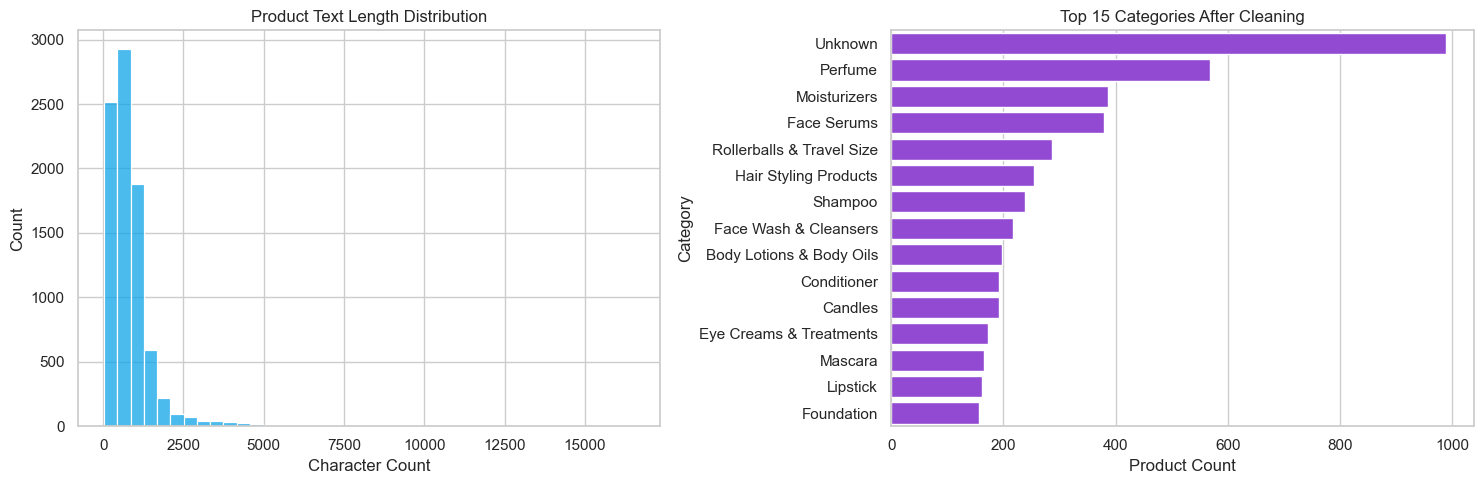

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(products_clean["product_text"].str.len(), bins=40, ax=axes[0], color="#0EA5E9")
axes[0].set_title("Product Text Length Distribution")
axes[0].set_xlabel("Character Count")

category_counts = products_clean["tertiary_category"].fillna("Unknown").value_counts().head(15).reset_index()
category_counts.columns = ["category", "count"]
sns.barplot(data=category_counts, x="count", y="category", ax=axes[1], color="#9333EA")
axes[1].set_title("Top 15 Categories After Cleaning")
axes[1].set_xlabel("Product Count")
axes[1].set_ylabel("Category")

plt.tight_layout()


## Grafik Yorumu

`product_text` uzunluk dağılımı content-based modelde kullanılacak metin temsilinin yeterli bilgi taşıyıp taşımadığını anlamak için önemlidir. Kategori dağılımı ise temizleme sonrasında veri setinin hangi ürün türlerinde yoğunlaştığını göstermektedir.


## Interaction Tables For Collaborative Filtering

Aynı kullanıcı aynı ürünü birden fazla kez değerlendirmiş olabileceği için üç ayrı strateji hazırlanır:
- son puan
- ilk puan
- ortalama puan


In [4]:
reviews = reviews.drop(columns=["Unnamed: 0"], errors="ignore").copy()
reviews["submission_time"] = pd.to_datetime(reviews["submission_time"], errors="coerce")
reviews["author_id"] = reviews["author_id"].astype(str)
reviews["product_id"] = reviews["product_id"].astype(str)

cf_base = reviews[["author_id", "product_id", "rating", "submission_time"]].copy()

cf_last = (
    cf_base.sort_values(["author_id", "product_id", "submission_time"])
    .drop_duplicates(subset=["author_id", "product_id"], keep="last")
)

cf_first = (
    cf_base.sort_values(["author_id", "product_id", "submission_time"])
    .drop_duplicates(subset=["author_id", "product_id"], keep="first")
)

cf_mean = (
    cf_base.groupby(["author_id", "product_id"], as_index=False)["rating"]
    .mean()
)

cf_summary = pd.DataFrame({
    "dataset": ["cf_last", "cf_first", "cf_mean"],
    "rows": [len(cf_last), len(cf_first), len(cf_mean)]
})

display(cf_summary)


,dataset,rows
0,cf_last,1088886
1,cf_first,1088886
2,cf_mean,1088886


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_54983/3726100650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cf_summary, x="dataset", y="rows", palette="viridis")


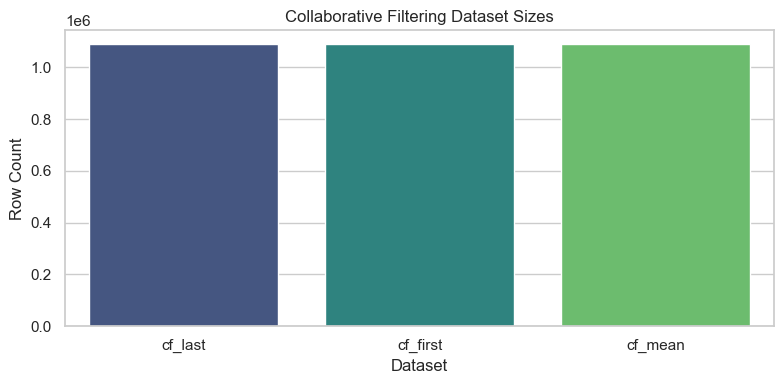

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cf_summary, x="dataset", y="rows", palette="viridis")
plt.title("Collaborative Filtering Dataset Sizes")
plt.xlabel("Dataset")
plt.ylabel("Row Count")
plt.tight_layout()


## Grafik Yorumu

Üç farklı collaborative filtering tablosunun satır sayılarının birbirine yakın olması, temel veri hacminin korunduğunu göstermektedir. Buna karşın kullanılan strateji, kullanıcı-ürün ilişkisinin nasıl temsil edildiğini etkilediği için daha sonraki model performansını da değiştirebilir.


## Full Review Feature Table

Bu tablo evaluation sırasında profile-based modeli kurabilmek için kullanıcı profil alanlarını da taşır.


In [6]:
reviews_full_features = reviews[[
    "author_id",
    "product_id",
    "rating",
    "submission_time",
    "skin_type",
    "skin_tone",
    "eye_color",
    "hair_color",
    "is_recommended",
]].copy()

reviews_full_features = (
    reviews_full_features.sort_values(["author_id", "product_id", "submission_time"])
    .drop_duplicates(subset=["author_id", "product_id"], keep="last")
)

display(reviews_full_features.head())


,author_id,product_id,rating,submission_time,skin_type,skin_tone,eye_color,hair_color,is_recommended
90306,10000015049,P427417,5,2019-03-08,combination,fair,green,brown,1.0
1070082,1000001620,P467115,4,2021-02-27,oily,fair,blue,blonde,1.0
602451,10000049623,P422003,5,2019-09-13,combination,light,brown,brown,1.0
43440,10000060335,P269122,5,2019-08-10,oily,fair,blue,blonde,1.0
150709,10000098796,P126301,5,2017-08-14,NaN,NaN,NaN,NaN,NaN


## Neden Bu Tabloyu Saklıyoruz?

`reviews_full_features.csv` dosyası, evaluation aşamasında kullanıcı profil alanlarını kaybetmeden train-test ayrımı yapabilmek için üretilmiştir. Böylece profile-based model de diğer modellerle aynı deney düzeninde karşılaştırılabilecektir.


## Product Profile Table

Bu bölümde skin type ve skin tone bazlı ürün skorları hesaplanır.


In [7]:
reviews_profile = reviews[[
    "product_id",
    "rating",
    "skin_type",
    "skin_tone",
    "eye_color",
    "hair_color",
    "is_recommended",
]].copy()

skin_reviews = reviews_profile.dropna(subset=["skin_type"]).copy()
global_mean_skin = skin_reviews["rating"].mean()
m = 20

product_skin_weighted = (
    skin_reviews.groupby(["product_id", "skin_type"]).agg(
        mean_rating=("rating", "mean"),
        review_count=("rating", "count"),
        recommend_rate=("is_recommended", "mean"),
    ).reset_index()
)

product_skin_weighted["weighted_score"] = (
    (product_skin_weighted["mean_rating"] * product_skin_weighted["review_count"] + global_mean_skin * m)
    / (product_skin_weighted["review_count"] + m)
)

skin_score_pivot = product_skin_weighted.pivot(index="product_id", columns="skin_type", values="weighted_score").reset_index()
skin_count_pivot = product_skin_weighted.pivot(index="product_id", columns="skin_type", values="review_count").reset_index()
skin_score_pivot = skin_score_pivot.rename(columns={c: f"{c}_score" for c in skin_score_pivot.columns if c != "product_id"})
skin_count_pivot = skin_count_pivot.rename(columns={c: f"{c}_count" for c in skin_count_pivot.columns if c != "product_id"})

tone_reviews = reviews_profile.dropna(subset=["skin_tone"]).copy()
global_mean_tone = tone_reviews["rating"].mean()

product_tone_weighted = (
    tone_reviews.groupby(["product_id", "skin_tone"]).agg(
        mean_rating=("rating", "mean"),
        review_count=("rating", "count"),
        recommend_rate=("is_recommended", "mean"),
    ).reset_index()
)

product_tone_weighted["weighted_score"] = (
    (product_tone_weighted["mean_rating"] * product_tone_weighted["review_count"] + global_mean_tone * m)
    / (product_tone_weighted["review_count"] + m)
)

tone_score_pivot = product_tone_weighted.pivot(index="product_id", columns="skin_tone", values="weighted_score").reset_index()
tone_count_pivot = product_tone_weighted.pivot(index="product_id", columns="skin_tone", values="review_count").reset_index()
tone_score_pivot = tone_score_pivot.rename(columns={c: f"{c}_tone_score" for c in tone_score_pivot.columns if c != "product_id"})
tone_count_pivot = tone_count_pivot.rename(columns={c: f"{c}_tone_count" for c in tone_count_pivot.columns if c != "product_id"})

product_profile = skin_score_pivot.merge(skin_count_pivot, on="product_id", how="left")
product_profile = product_profile.merge(tone_score_pivot, on="product_id", how="left")
product_profile = product_profile.merge(tone_count_pivot, on="product_id", how="left")
product_profile["product_id"] = product_profile["product_id"].astype(str)

display(product_profile.head())


,product_id,combination_score,dry_score,normal_score,oily_score,combination_count,dry_count,normal_count,oily_count,dark_tone_score,...,fairLight_tone_count,light_tone_count,lightMedium_tone_count,medium_tone_count,mediumTan_tone_count,notSureST_tone_count,olive_tone_count,porcelain_tone_count,rich_tone_count,tan_tone_count
0,P107306,4.091233,4.399191,4.360669,3.498844,111.0,40.0,27.0,22.0,4.138173,...,4.0,48.0,39.0,9.0,16.0,NaN,1.0,1.0,NaN,2.0
1,P114902,4.388902,4.383157,4.478207,4.475656,525.0,66.0,74.0,249.0,NaN,...,20.0,296.0,205.0,26.0,82.0,NaN,NaN,NaN,NaN,38.0
2,P12045,4.476965,4.393983,4.404210,4.399676,655.0,254.0,111.0,130.0,NaN,...,72.0,308.0,219.0,75.0,75.0,1.0,NaN,1.0,2.0,53.0
3,P122651,4.380375,4.494226,4.482305,4.377637,64.0,75.0,11.0,9.0,NaN,...,3.0,39.0,33.0,3.0,12.0,NaN,NaN,NaN,NaN,2.0
4,P122661,4.459380,4.585148,4.583785,4.262519,252.0,91.0,57.0,56.0,NaN,...,6.0,180.0,101.0,5.0,46.0,NaN,NaN,NaN,1.0,15.0


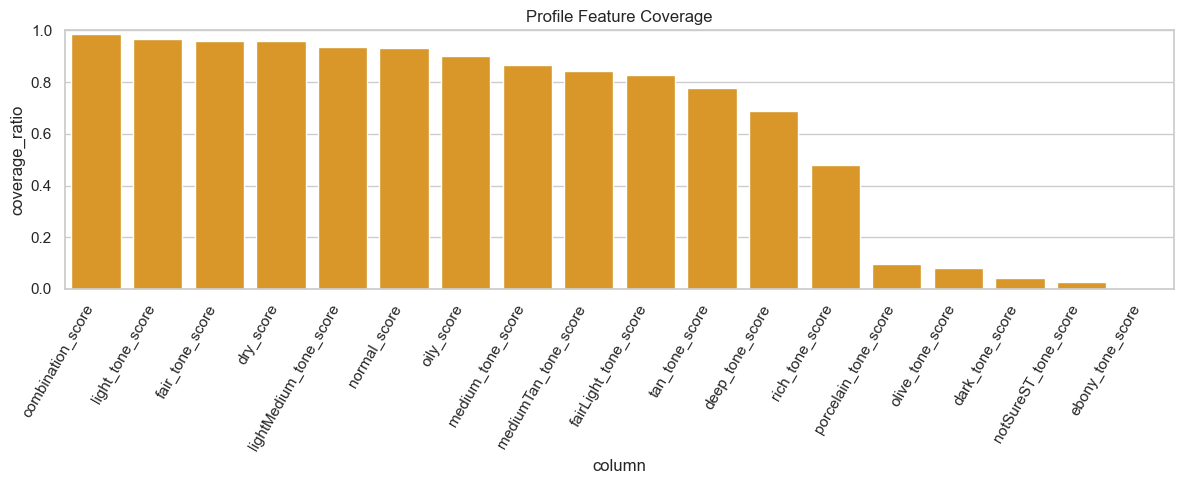

In [8]:
profile_coverage = pd.DataFrame({
    "column": [col for col in product_profile.columns if col.endswith("_score")],
})
profile_coverage["coverage_ratio"] = profile_coverage["column"].map(lambda col: product_profile[col].notna().mean())
profile_coverage = profile_coverage.sort_values("coverage_ratio", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=profile_coverage, x="column", y="coverage_ratio", color="#F59E0B")
plt.title("Profile Feature Coverage")
plt.ylim(0, 1)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()


## Grafik Yorumu

Profile feature coverage grafiği, skin type ve skin tone tabanlı skorların bütün ürünlerde eşit yoğunlukta oluşmadığını göstermektedir. Bu sonuç profile-based modelin açıklanabilir olmasına rağmen veri yoğunluğuna duyarlı olduğunu ortaya koyar.

Örnek tez cümlesi:
"Profil tabanlı sinyaller tüm ürünlerde aynı düzeyde gözlenmediğinden, bu yaklaşım veri yoğunluğu yüksek segmentlerde daha güvenilir sonuçlar üretirken bazı ürünlerde sınırlı kapsama sahiptir."


In [9]:
products_clean.to_csv(DATA_INTERIM / "products_clean.csv", index=False)
cf_last.to_csv(DATA_INTERIM / "reviews_cf_last.csv", index=False)
cf_first.to_csv(DATA_INTERIM / "reviews_cf_first.csv", index=False)
cf_mean.to_csv(DATA_INTERIM / "reviews_cf_mean.csv", index=False)
reviews_full_features.to_csv(DATA_INTERIM / "reviews_full_features.csv", index=False)
product_profile.to_csv(DATA_INTERIM / "product_profile.csv", index=False)

print("Saved all preprocessing outputs to data_interim/")


Saved all preprocessing outputs to data_interim/


## Produced Files

Bu notebook çalıştıktan sonra model notebook'ları doğrudan `data_interim/` klasöründeki dosyaları kullanmalıdır.


## Çalıştırma Notu

Bu notebook tamamlandıktan sonra diğer tüm model notebook'ları sadece `data_interim/` klasöründeki çıktılar üzerinden ilerlemelidir. Bu yaklaşım tekrar üretilebilirliği artırır ve tezde veri hazırlama sürecini tek bir merkezde toplar.
